# Modularisation in Python

Notebooks are a great way to write and run code, but they can become unmanageable as they grow larger. 

**Modularisation** is the process of breaking down code into smaller, reusable pieces. In Python, an easy way to achieve modularisation is by using **modules** and **functions**.

A **module** is a file containing Python definitions and statements. The file name is the module name with the suffix `.py` added. Modules can define functions, classes, and variables, and can also include runnable code (we have seen a bit of this in a [previous lecture](../11/lecture_beyond_the_notebook.ipynb)).

Notice that a module **is not** a notebook: it is a **pure text** file containing Python code. It can be edited and viewed in Noteable or any other editor.


## Jupyter Lab

When launching Noteable, you have mostly used the *Classic Jupyter (Legacy)* interface. However, Noteable support many other interfaces.

The *Jupyter Lab* interface is a more modern and feature-rich interface for working with Jupyter notebooks. It provides a more flexible and powerful environment for working with notebooks, code, and data.

In this session, it will be useful to use the Jupyter Lab interface, as it allows us to easily view and edit module files alongside our notebooks.

you access it by selecting **Standard Python 3** from the initial dropdown menu.

![selecting Jupyter Lab interface](./images/select.png)

After launching, the interface should look like this (or similar):


![main](./images/main.png)

## Using a module file from a notebook

In this lecture notebook, we focus on using a module file (a `.py` file) from a notebook.

We will use `plot_example.py` -- present in this same directory --  which contains plotting functions created from code patterns used in class.



## What is in the module?

If we open `plot_example.py`, we can see import statements and function definitions such as `time_scatter()`.

<img src="images/plot_example_screenshot_1.png" alt="plot_example module" style="display:block;margin-left:auto;margin-right:auto;width:60%"/>

We immediately recognise the same code structure as in our previous code:

- import statements at the top of the file
- function definitions below   

Syntax highlighting and indentation make it easy to read and understand the code structure.

## Importing a module

To access functions in the file, import the module name (without `.py`).

This works because `plot_example.py` is in the same folder as this notebook (a relative import).

In [1]:
import plot_example

More generally, specific paths to files can be used using a particular syntax:

- `import plot_example` (if the file is in the same folder as the notebook)
- `import folder_name.plot_example` (if the file is in a subfolder of the notebook)
- `import ..folder_name.plot_example` (if the file is in a parent folder of the notebook)   

It is recommended to use relative imports (i.e. the first two options) when working on a project, as they are more portable and easier to manage.


Once the module is imported, all functions and variables defined in the module are available for use in the notebook. You can then access module functions with dot syntax, e.g. `plot_example.time_scatter(...)`.

## Introspection

Suppose we are give a module from a friend or colleague and we want to know what functions are available in the module. We can use **introspection** to inspect the module and find out what functions it contains.

Introspection is the ability of a program to examine the type or properties of an object at runtime. In Python, we can use the `dir()` function to get a list of all the actions and properties possessed by any object in python (i.e. any names including functions, variables, etc.).

This is powerful because it allows us to **explore** and **understand** the contents of a module without having to read through the entire code. 

A convention in Python is that if we write our own module and want to hide some properties to a final user (i.e. we don't want them to be accessed directly), we can prefix the name of these properties with an underscore (e.g. `_hidden_function()`). This is a convention, not a strict rule, but it is widely followed in the Python community.



### Example: inspect available functions

Suppose we want to know what functions are available in the `plot_example` module.

We could try `dir()`


In [5]:
dir(plot_example)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'np',
 'plot_population_stacked',
 'plot_uncert',
 'plt',
 'time_scatter']

As you see, this would yield a long list of names, including functions, variables, and other properties. To filter out the functions, we can use a list comprehension to exclude any names that start with an underscore (as these are typically used for internal purposes and are not meant to be accessed directly by users):

In [6]:
# we are using dir() to inspect the contents of the module and find out what functions it contains
# we exclude any names that start with an underscore, as these are typically used for internal purposes 
# and are not meant to be accessed directly by users
[name for name in dir(plot_example) if not name.startswith('_')]

['np', 'plot_population_stacked', 'plot_uncert', 'plt', 'time_scatter']

### Importing one function directly

We can be very selective when importing from a module. As we did with `numpy` or event `plotly`, we can instruct Python to import only specific functions from a module.

If you only need one function, you can import it directly using `from ... import ...`.

In [9]:
## in this case, we import a custom function from our module
from plot_example import time_scatter

In [10]:
import numpy as np
import matplotlib.pyplot as plt

time = np.arange(0, 10, 0.1)
y = np.linspace(0, 5, len(time))**2

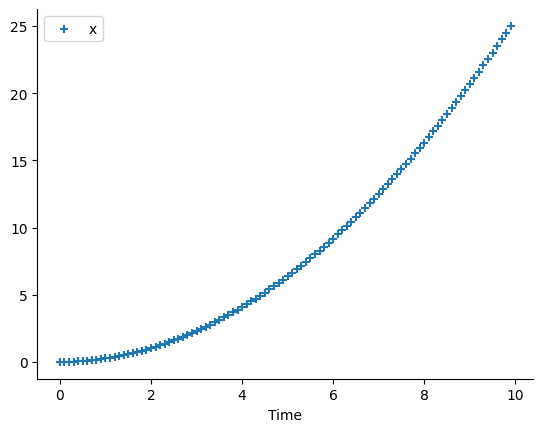

In [11]:
fig, ax = plt.subplots()
time_scatter(time, y, ax, label='x')

Clearly, our function `time_scatter()` is available in the module and must be wrapping specific plotting code. As for any other python function, we can use `help()` to get more information about how to use it.


In [13]:
help(time_scatter)

Help on function time_scatter in module plot_example:

time_scatter(times, y, ax=None, label=None)
    Simple time scatter plot with legend
    Args:
        times (list/iterable) : 
            List (or other ordered container) with the time values in seconds
        y (list/iterable) : 
            Value to plot against time
        ax (matplotlib.pyplot.Axes/None, optional) : 
            Axes object to use for plotting
        label (str/None, optional) : 
            Label to include within the legend
    Returns:
        None
        Modifies `ax` input to add features.



This retrieves the **docstring** of the function, which is a string that describes what the function does, its parameters, and its return value. This information is crucial for understanding how to use the function correctly. You shoudl be able to see it directly inside the module file, as a string immediately following the function definition.

We can also inspect the code of the function itself by using `??`:

In [14]:
time_scatter??

Signature: time_scatter(times, y, ax=None, label=None)
Source:   
def time_scatter(times, y, ax=None, label=None):
    '''
    Simple time scatter plot with legend
    Args:
        times (list/iterable) : 
            List (or other ordered container) with the time values in seconds
        y (list/iterable) : 
            Value to plot against time
        ax (matplotlib.pyplot.Axes/None, optional) : 
            Axes object to use for plotting
        label (str/None, optional) : 
            Label to include within the legend
    Returns:
        None
        Modifies `ax` input to add features.
    '''
    if ax is None:
        fig, ax = plt.subplots()

    ax.scatter(times, y, label = label, marker='+')
    ax.set_xlabel("Time")
    if label is not None:
        ax.legend()
File:      ~/Repos/intro-coding-data-analysis/19/plot_example.py
Type:      function

Notice that the `??` command exposes what is called as the **signature** of the function, which shows the parameters that the function takes and their default values (if any). This is very useful for understanding how to call the function correctly.

It also presents the first few lines of the function code, which can be helpful for understanding how the function works and what it does.  In this case we get most of the initial docstring: notice that **triple quotes** are used to write multi-line docstrings, which can be very useful for providing detailed documentation for functions.

A useful docstring should include:

- A brief description of what the function **does**
- A description of the **parameters**, including their types and what they represent
- A description of the **return value(s)**, including their type and what they represents  

There is an even more direct way to access the docstring of a function: by using the `__doc__` attribute of the function, e.g. `time_scatter.__doc__`. Basically we access a specific (hidden) property of the function that contains the docstring, and get it as a genuine python string. This is yet another example of accessing features of Python objects using dot syntax, a hint to the Object Oriented Programming (OOP) paradigm that you will see in the future.

In [18]:
docstring = time_scatter.__doc__
print(docstring)


    Simple time scatter plot with legend
    Args:
        times (list/iterable) : 
            List (or other ordered container) with the time values in seconds
        y (list/iterable) : 
            Value to plot against time
        ax (matplotlib.pyplot.Axes/None, optional) : 
            Axes object to use for plotting
        label (str/None, optional) : 
            Label to include within the legend
    Returns:
        None
        Modifies `ax` input to add features.
    


## Important: making changes to a module

When working with modules, files are edited frequently and eventually imported in notebooks. 

But notebooks do not automatically reload the module when it is changed, which can cause many headaches if you are not aware of it!

There are two ways to ensure that your notebook uses the latest module code:

1. The simplest is to simply **restart the kernel** and **run all notebook cells** after **saving** the module file. This ensures your notebook uses the latest module code.
2. A more advanced way is to use the `importlib` library to reload the module without restarting the kernel. This can be done with the following code:

```python
import importlib
import plot_example
## ensure that the latest version of the module is used
importlib.reload(plot_example)
```

Using `importlib.reload()` is particularly useful when you are actively developing a module and want to test changes without restarting the kernel.

It allows you not to lose the state of your notebook (e.g. variables, imports, etc.) while still ensuring that you are using the latest version of the module.

## Catching exceptions

When working with modules, it is common to encounter errors or exceptions: these can be due to syntax errors in the module code, missing dependencies, or incorrect usage of functions.

This is because the final use is often blind to the details of the module code, and relies on the module to work correctly. 

This means that we code modules it is important that we strive to consider possible exceptions and errors that may arise, and to handle them gracefully without crashing the entire program.

For this purpose, Python has a built-in syntax that helps with handling such situations: the `try-except` block. This allows us to catch exceptions and handle them in a way that does not crash the entire program, but instead provides useful feedback to the user or takes corrective action.

The starting point is to note that errors in Python are associated with specific types: for example, a `SyntaxError` is raised when there is a syntax error in the code, while a `NameError` is raised when a variable or function name is not defined.



In [19]:
2-== 2

SyntaxError: invalid syntax (4146853217.py, line 1)

In [21]:
variable_that_does_not_exist_yet


NameError: name 'variable_that_does_not_exist_yet' is not defined

Exceptions use the error type information to construct a conditional flow of the program: if a specific type of error is raised, the program can execute a specific block of code to handle that error. 

Fore example, if a `NameError` is raised, we can catch it and print a message to the user indicating that a variable or function name is not defined, instead of crashing the entire program.

To do so we have a block where:

- the `try` keyword is used to indicate the block of code that we want to execute and that may raise an exception
- the `except` keyword is used to indicate the block of code that we want to execute
- the `else` keyword can be used to indicate a block of code that should be executed if no exceptions are raised in the `try` block
- the `finally` keyword can be used to indicate a block of code that should be executed regardless of whether an exception was raised or not, typically used for cleanup actions (e.g. closing files, releasing resources, etc.)

For example, in the following code, we try to divide a number by zero, which raises a `ZeroDivisionError`. We catch this specific error and print a message to the user indicating that you cannot divide by zero, instead of crashing the entire program.

In [27]:
value = 0 # change this to a non-zero value to see the else block in action

try:
    result = 10 / value
except ZeroDivisionError:
    print("You cannot divide by zero.")
else:
    print("The result is:", result)
finally:
    print("I am done with the division operation.")

You cannot divide by zero.
I am done with the division operation.


Notice that *throwing an exception* means that an error is raised during the execution of the code, while *catching an exception* means that we handle the error without crashing the program.

Catching exceptions significantly improves our modules:

- it allows us to enforce correct usage of our functions
- it provides useful feedback to users when they make mistakes
- it prevents our programs from crashing due to errors

Take our original code for `time_scatter()` as an example: according to its *signature* and *docstring*, it expects sequences for the `x` and `y` parameters. If a user accidentally passes a non-sequence (e.g. a single number), this raises errors:

In [28]:
time_scatter(1, 2, 3)

AttributeError: 'int' object has no attribute 'scatter'

We can use a `try-except` block to catch specific exceptions that may arise and provide a useful error message to the user, instead of crashing the entire program:

```python
def time_scatter(x, y):
    try:
        # original code for time_scatter() goes here
    except Exception as e:
        print(f"Errors occurred, possibly wrong inputs\n {e}")
    else:
        print("Plot created successfully.")
```

Notice that here we catch all kinds of exceptions and also catch the error message itself (using `as e`) to provide more specific feedback to the user about what went wrong. This is a common practice when catching exceptions, as it allows us to provide more informative error messages that can help users understand and fix their mistakes.